In [ ]:
# Complete Updated Script: EWC with plotting and checkpoints (TensorFlow 2.x)
# Make sure required packages are installed:
# pip install tensorflow matplotlib seaborn opencv-python kagglehub tqdm

import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import tensorflow as tf

# ------------------- CONFIG -------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Dataset download / path (adjust if using Colab Drive)
USE_KAGGLEHUB = True   # set False if you already have DATA_DIR
DATA_DIR = "archive"   # fallback root
# If using kagglehub, dataset will be downloaded under current working dir
# (This code uses a user-provided kagglehub call; ensure kagglehub is installed and configured)
# ------------------------------------------------

# If you want to use your previous kagglehub downloader, keep it; otherwise set DATA_DIR manually.
if USE_KAGGLEHUB:
    try:
        import kagglehub
        path = kagglehub.dataset_download("puneet6060/intel-image-classification")
        print("kagglehub returned path:", path)
        DATA_DIR = path
    except Exception as e:
        print("kagglehub download failed or not available:", e)
        # assume archive exists at ./archive (user already had dataset)
        DATA_DIR = "archive"

train_dir = os.path.join(DATA_DIR, "seg_train", "seg_train")
test_dir  = os.path.join(DATA_DIR, "seg_test", "seg_test")

assert os.path.exists(train_dir), f"Train dir not found: {train_dir}"
assert os.path.exists(test_dir), f"Test dir not found: {test_dir}"
print("Using dataset at:", DATA_DIR)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
kagglehub returned path: /kaggle/input/intel-image-classification
Using dataset at: /kaggle/input/intel-image-classification


In [ ]:
# ------------------- TASK / SAMPLING SETUP -------------------
# Define two tasks and classes
classes_task1 = ['sea', 'forest']
classes_task2 = ['buildings', 'mountain']

# Number of samples to pick per class
TRAIN_PER_CLASS = 500   # reduce if memory/time limited
TEST_PER_CLASS  = 250

IMG_SIZE = 150  # you used 150 earlier
BATCH_SIZE = 32

# Utility: sample files for a class
def downsample_class(class_name, train_dir, test_dir, train_n=500, test_n=250):
    train_glob = glob.glob(os.path.join(train_dir, class_name, '*.jpg'))
    test_glob  = glob.glob(os.path.join(test_dir, class_name, '*.jpg'))
    if len(train_glob) < train_n or len(test_glob) < test_n:
        raise ValueError(f"Not enough images for class {class_name}. Found train={len(train_glob)}, test={len(test_glob)}")
    train_files = random.sample(train_glob, train_n)
    test_files  = random.sample(test_glob, test_n)
    return train_files, test_files

# Build lists (path,label)
train_task1, test_task1 = [], []
for i, cname in enumerate(classes_task1):
    files_train, files_test = downsample_class(cname, train_dir, test_dir, TRAIN_PER_CLASS, TEST_PER_CLASS)
    train_task1 += [(f, i) for f in files_train]
    test_task1  += [(f, i) for f in files_test]

train_task2, test_task2 = [], []
for i, cname in enumerate(classes_task2):
    files_train, files_test = downsample_class(cname, train_dir, test_dir, TRAIN_PER_CLASS, TEST_PER_CLASS)
    train_task2 += [(f, i) for f in files_train]
    test_task2  += [(f, i) for f in files_test]

print("Task1 train:", len(train_task1), "test:", len(test_task1))
print("Task2 train:", len(train_task2), "test:", len(test_task2))

Task1 train: 1000 test: 500
Task2 train: 1000 test: 500


In [ ]:
# ------------------- PREPROCESSING -------------------
def preprocess_img_label(img_label_tuples, img_size=IMG_SIZE):
    X, y = [], []
    for img_path, label in tqdm(img_label_tuples, desc="Preprocessing images"):
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError("Could not read image:", img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32) / 255.0
        X.append(img)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_train_1, y_train_1 = preprocess_img_label(train_task1)
X_test_1,  y_test_1  = preprocess_img_label(test_task1)
X_train_2, y_train_2 = preprocess_img_label(train_task2)
X_test_2,  y_test_2  = preprocess_img_label(test_task2)

print("Shapes:", X_train_1.shape, y_train_1.shape, X_test_1.shape, y_test_1.shape)

Preprocessing images: 100%|██████████| 500/500 [00:04<00:00, 118.14it/s]

Shapes: (1000, 150, 150, 3) (1000,) (500, 150, 150, 3) (500,)


In [ ]:
# ------------------- MODEL DEFINITION -------------------
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)
def build_resnet_binary(input_shape=IMG_SHAPE, freeze_backbone=True):
    base = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = (not freeze_backbone)
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_resnet_binary(freeze_backbone=True)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# ------------------- TRAIN TASK 1 (standard fit) -------------------
EPOCHS_TASK1 = 5
history1 = model.fit(X_train_1, y_train_1,
                     validation_data=(X_test_1, y_test_1),
                     epochs=EPOCHS_TASK1, batch_size=BATCH_SIZE)

# Save checkpoint after Task1 (for "before" evaluation)
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
task1_ckpt = os.path.join(CHECKPOINT_DIR, "model_after_task1.h5")
model.save(task1_ckpt)
print("Saved Task1 checkpoint to:", task1_ckpt)

# Evaluate Task1 after Task1 training (baseline)
t1_eval_after = model.evaluate(X_test_1, y_test_1, verbose=0)
print(f"Task1 test loss after Task1: {t1_eval_after[0]:.4f}, acc: {t1_eval_after[1]:.4f}")

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 451ms/step - accuracy: 0.4967 - loss: 0.7158 - val_accuracy: 0.7860 - val_loss: 0.6843
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.5306 - loss: 0.7077 - val_accuracy: 0.7680 - val_loss: 0.6767
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.5054 - loss: 0.7020 - val_accuracy: 0.5740 - val_loss: 0.6708
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.5690 - loss: 0.6752 - val_accuracy: 0.8620 - val_loss: 0.6644
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5555 - loss: 0.6782 - val_accuracy: 0.8340 - val_loss: 0.6581


Saved Task1 checkpoint to: checkpoints/model_after_task1.h5
Task1 test loss after Task1: 0.6581, acc: 0.8340


In [ ]:
# ------------------- FISHER COMPUTATION (diagonal approx) -------------------
trainable_vars = model.trainable_variables  # list of tf.Variables to protect

def compute_fisher_diagonal_tf(model, X, y, batch_size=32, num_batches=None):
    loss_fn = tf.keras.losses.BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
    dataset = tf.data.Dataset.from_tensor_slices((X, y)).batch(batch_size).shuffle(1000)
    total_seen = 0
    fisher_acc = [np.zeros(var.shape, dtype=np.float32) for var in trainable_vars]
    for i, (xb, yb) in enumerate(dataset):
        if num_batches is not None and i >= num_batches:
            break
        with tf.GradientTape() as tape:
            preds = model(xb, training=False)
            # scalar loss (mean over batch)
            loss = tf.reduce_mean(loss_fn(yb, preds))
        grads = tape.gradient(loss, trainable_vars)
        for j, g in enumerate(grads):
            if g is None:
                continue
            g_np = g.numpy()
            fisher_acc[j] += (g_np ** 2) * xb.shape[0]  # scale by number of examples
        total_seen += xb.shape[0]
    # normalize
    for j in range(len(fisher_acc)):
        fisher_acc[j] /= float(max(1, total_seen))
    return fisher_acc

print("Computing Fisher diagonal on Task1 training data (approx)...")
F_task1 = compute_fisher_diagonal_tf(model, X_train_1, y_train_1, batch_size=BATCH_SIZE, num_batches=50)
print("Fisher computed. Sample stats:")
flat_sample = np.concatenate([f.flatten() for f in F_task1[:min(10, len(F_task1))]])
print("Fisher mean (sample):", np.mean(flat_sample), "max:", np.max(flat_sample), "min:", np.min(flat_sample))

# Save snapshot theta_star
theta_star = [var.numpy().copy() for var in trainable_vars]

Computing Fisher diagonal on Task1 training data (approx)...
Fisher computed. Sample stats:
Fisher mean (sample): 0.0004823606 max: 2.0207434 min: 0.0


In [ ]:
# ------------------- TRAIN TASK 2 WITH EWC (custom loop) -------------------
def train_with_ewc_tf(model, X_train, y_train, X_val, y_val,
                      fisher_diagonal, theta_star,
                      lambda_ewc=1000.0, epochs=5, batch_size=32, lr=1e-4):
    optimizer = tf.keras.optimizers.Adam(lr)
    loss_fn = tf.keras.losses.BinaryCrossentropy()
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size)
    val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

    # convert fisher/theta to tf constants
    fisher_tf = [tf.constant(f.astype(np.float32)) for f in fisher_diagonal]
    theta_tf  = [tf.constant(t.astype(np.float32)) for t in theta_star]

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'task_loss_epoch': [], 'ewc_penalty_epoch': [], 'total_loss_epoch': []
    }

    for epoch in range(epochs):
        print(f"\nEWC Epoch {epoch+1}/{epochs}")
        train_loss_accum = 0.0
        epoch_task_loss_sum = 0.0
        epoch_ewc_penalty_sum = 0.0
        steps = 0
        metric_acc = tf.keras.metrics.BinaryAccuracy()

        for xb, yb in train_ds:
            with tf.GradientTape() as tape:
                preds = model(xb, training=True)
                task_loss = tf.reduce_mean(loss_fn(yb, preds))
                # EWC penalty
                ewc_penalty = 0.0
                for var, f, t in zip(model.trainable_variables, fisher_tf, theta_tf):
                    ewc_penalty += tf.reduce_sum(f * tf.square(var - t))
                ewc_penalty *= (0.5 * lambda_ewc)
                loss = task_loss + ewc_penalty

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            train_loss_accum += loss.numpy()
            epoch_task_loss_sum += task_loss.numpy()
            epoch_ewc_penalty_sum += ewc_penalty.numpy()
            metric_acc.update_state(yb, preds)
            steps += 1

        # validation
        val_loss_metric = tf.keras.metrics.Mean()
        val_acc_metric  = tf.keras.metrics.BinaryAccuracy()
        for xb, yb in val_ds:
            preds = model(xb, training=False)
            val_loss_metric.update_state(tf.reduce_mean(loss_fn(yb, preds)))
            val_acc_metric.update_state(yb, preds)

        avg_train_loss = train_loss_accum / max(1, steps)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(metric_acc.result().numpy())
        history['val_loss'].append(val_loss_metric.result().numpy())
        history['val_acc'].append(val_acc_metric.result().numpy())
        history['task_loss_epoch'].append(epoch_task_loss_sum / max(1, steps))
        history['ewc_penalty_epoch'].append(epoch_ewc_penalty_sum / max(1, steps))
        history['total_loss_epoch'].append(avg_train_loss)

        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {metric_acc.result().numpy():.4f}")
        print(f"Val   Loss: {val_loss_metric.result().numpy():.4f}, Val   Acc: {val_acc_metric.result().numpy():.4f}")

    return model, history

lambda_ewc = 1000.0
EPOCHS_TASK2 = 5

model, history_ewc = train_with_ewc_tf(
    model,
    X_train_2, y_train_2,
    X_test_2, y_test_2,
    fisher_diagonal=F_task1,
    theta_star=theta_star,
    lambda_ewc=lambda_ewc,
    epochs=EPOCHS_TASK2,
    batch_size=BATCH_SIZE,
    lr=1e-4
)


EWC Epoch 1/5
Train Loss: 0.7175, Train Acc: 0.4730
Val   Loss: 0.7023, Val   Acc: 0.3180

EWC Epoch 2/5
Train Loss: 0.7065, Train Acc: 0.4750
Val   Loss: 0.6905, Val   Acc: 0.5360

EWC Epoch 3/5
Train Loss: 0.6992, Train Acc: 0.5290
Val   Loss: 0.6801, Val   Acc: 0.6540

EWC Epoch 4/5
Train Loss: 0.6956, Train Acc: 0.5390
Val   Loss: 0.6729, Val   Acc: 0.6840

EWC Epoch 5/5
Train Loss: 0.6891, Train Acc: 0.5620
Val   Loss: 0.6650, Val   Acc: 0.7140


Saved final model to: checkpoints/model_after_task2_ewc.h5


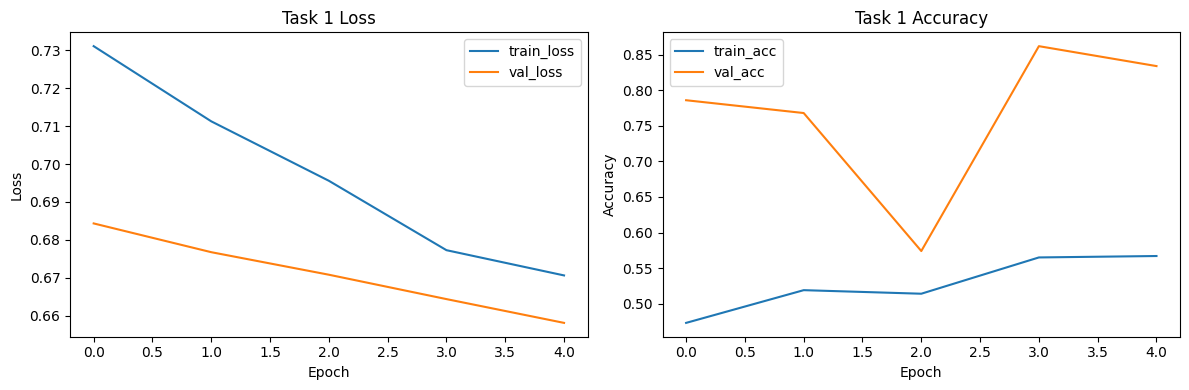

In [ ]:
# Save final model
final_ckpt = os.path.join(CHECKPOINT_DIR, "model_after_task2_ewc.h5")
model.save(final_ckpt)
print("Saved final model to:", final_ckpt)

# ------------------- EVALUATION & PLOTTING -------------------
# 1) Task1 training curves (history1)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label='train_loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.title('Task 1 Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history1.history['accuracy'], label='train_acc')
plt.plot(history1.history['val_accuracy'], label='val_acc')
plt.title('Task 1 Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

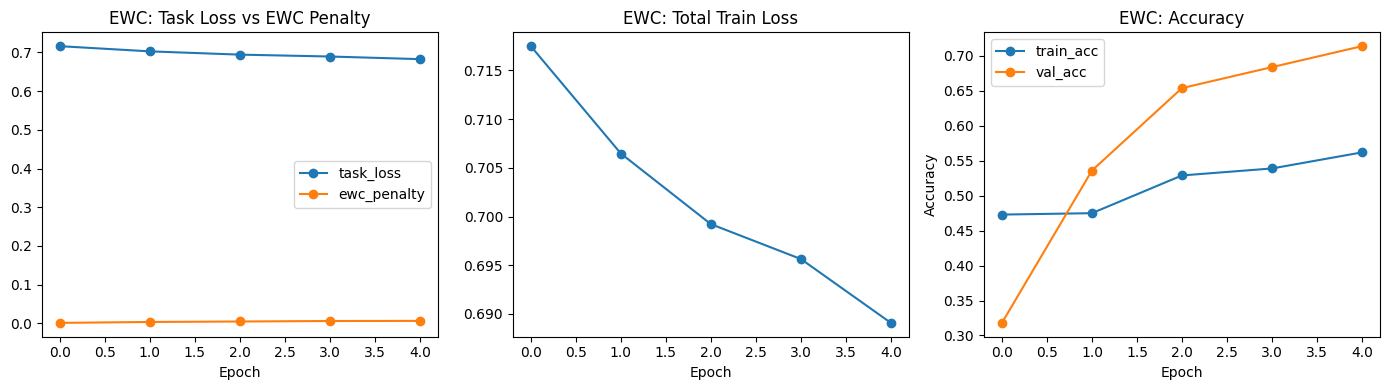

In [ ]:
# 2) EWC training curves (history_ewc)
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.plot(history_ewc['task_loss_epoch'], marker='o', label='task_loss')
plt.plot(history_ewc['ewc_penalty_epoch'], marker='o', label='ewc_penalty')
plt.title('EWC: Task Loss vs EWC Penalty')
plt.xlabel('Epoch'); plt.legend()
plt.subplot(1,3,2)
plt.plot(history_ewc['total_loss_epoch'], marker='o')
plt.title('EWC: Total Train Loss')
plt.xlabel('Epoch')
plt.subplot(1,3,3)
plt.plot(history_ewc['train_acc'], marker='o', label='train_acc')
plt.plot(history_ewc['val_acc'], marker='o', label='val_acc')
plt.title('EWC: Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.tight_layout(); plt.show()

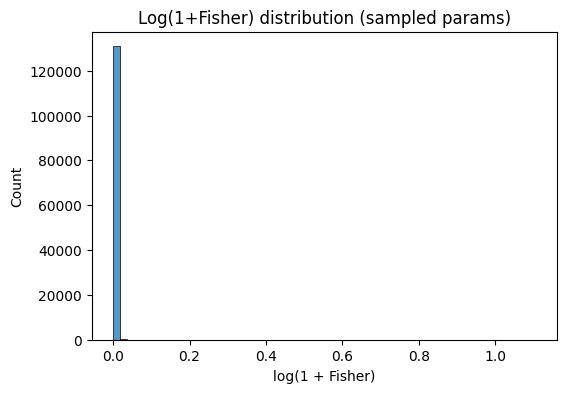

In [ ]:
# 3) Fisher histogram (sample)
f_flat = np.concatenate([f.flatten() for f in F_task1[:min(10, len(F_task1))]])
f_flat = f_flat[np.isfinite(f_flat)]
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(f_flat), bins=60)
plt.title('Log(1+Fisher) distribution (sampled params)')
plt.xlabel('log(1 + Fisher)'); plt.show()

Task1 val acc after Task1: 0.8340
Task1 test acc after Task2+EWC: 0.5560


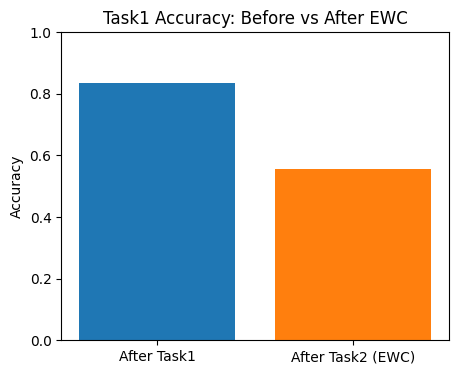

In [ ]:
# 4) Task1 accuracy before vs after (bar)
acc_t1_after = history1.history['val_accuracy'][-1]
eval_t1_after_ewc = model.evaluate(X_test_1, y_test_1, verbose=0)
acc_t1_after_ewc = eval_t1_after_ewc[1]
print(f"Task1 val acc after Task1: {acc_t1_after:.4f}")
print(f"Task1 test acc after Task2+EWC: {acc_t1_after_ewc:.4f}")

plt.figure(figsize=(5,4))
plt.bar(['After Task1', 'After Task2 (EWC)'], [acc_t1_after, acc_t1_after_ewc], color=['tab:blue','tab:orange'])
plt.ylim(0,1); plt.ylabel('Accuracy'); plt.title('Task1 Accuracy: Before vs After EWC')
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms/step


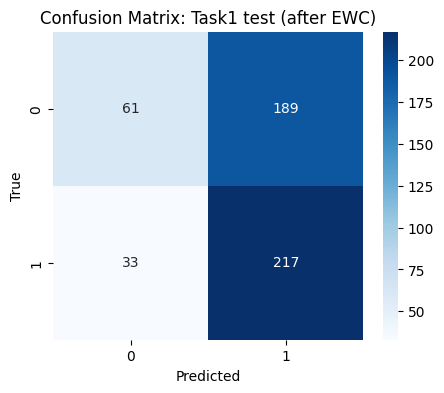

In [ ]:
# 5) Confusion matrix on Task1 test set after EWC
preds_t1 = (model.predict(X_test_1) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test_1, preds_t1)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Task1 test (after EWC)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


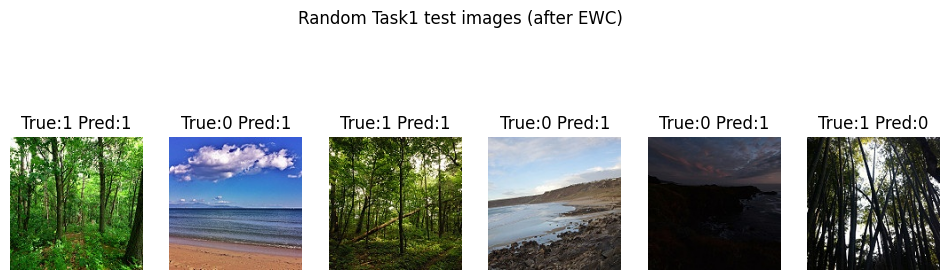

In [ ]:
# 6) Optional: Show a few sample images and their predictions (Task1 test)
n_show = 6
inds = np.random.choice(len(X_test_1), size=n_show, replace=False)
plt.figure(figsize=(12,4))
for i, idx in enumerate(inds):
    plt.subplot(1, n_show, i+1)
    plt.imshow(X_test_1[idx])
    p = (model.predict(X_test_1[idx:idx+1]) > 0.5).astype(int)[0][0]
    plt.title(f"True:{y_test_1[idx]} Pred:{p}")
    plt.axis('off')
plt.suptitle("Random Task1 test images (after EWC)")
plt.show()

In [ ]:
# ------------------- KEY TAKEAWAYS (printed) -------------------
print("\nKEY TAKEAWAYS / HOW TO INTERPRET PLOTS:")
print("1) Task1 loss/acc plots show whether Task1 was learned well initially (overfitting signs: train loss << val loss).")
print("2) EWC plots: if 'ewc_penalty' is large relative to 'task_loss', EWC is strongly constraining updates (lambda too high).")
print("3) Fisher histogram indicates how many params are 'important' for Task1 (heavy tail = few important params).")
print("4) Bar chart Task1 accuracy before vs after indicates forgetting magnitude: lower drop => better retention.")
print("5) Confusion matrix shows class-level errors after Task2; inspect which classes are most affected.")
print("\nSuggested next steps:")
print("- tune lambda_ewc (try values 10,100,500,1000), increase/decrease fisher sample size, or apply EWC only to top-k important params or to classifier layers if model too constrained.")


KEY TAKEAWAYS / HOW TO INTERPRET PLOTS:
1) Task1 loss/acc plots show whether Task1 was learned well initially (overfitting signs: train loss << val loss).
2) EWC plots: if 'ewc_penalty' is large relative to 'task_loss', EWC is strongly constraining updates (lambda too high).
3) Fisher histogram indicates how many params are 'important' for Task1 (heavy tail = few important params).
4) Bar chart Task1 accuracy before vs after indicates forgetting magnitude: lower drop => better retention.
5) Confusion matrix shows class-level errors after Task2; inspect which classes are most affected.

Suggested next steps:
- tune lambda_ewc (try values 10,100,500,1000), increase/decrease fisher sample size, or apply EWC only to top-k important params or to classifier layers if model too constrained.


100%|██████████| 346M/346M [00:02<00:00, 153MB/s]

Extracting files...


Task1 train/test sizes: 1000 500
Task2 train/test sizes: 1000 500


Preprocessing images: 100%|██████████| 500/500 [00:00<00:00, 1608.36it/s]


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Training Task 1 (unchanged) ---
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 466ms/step - accuracy: 0.5049 - loss: 0.7147 - val_accuracy: 0.7880 - val_loss: 0.6839
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5258 - loss: 0.7085 - val_accuracy: 0.6720 - val_loss: 0.6769
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5019 - loss: 0.7022 - val_accuracy: 0.5440 - val_loss: 0.6710
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5733 - loss: 0.6743 - val_accuracy: 0.8520 - val_loss: 0.6642
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5530 - loss: 0.6764 - val_accuracy: 0.8200 - val_loss: 0.6578


Saved Task1 checkpoint: checkpoints/model_after_task1.h5
Task1 test after Task1 training: loss=0.6578, acc=0.8200

--- Computing Fisher diagonal (unchanged) ---
Computed Fisher (sample stats):
Fisher sample mean: 1.5851778e-05 5%: 0.0 95%: 8.288625e-08 max: 0.06600131

--- Training Task 2 with EWC (unchanged) ---

EWC Epoch 1/5
Train Loss: 0.7187, Train Acc: 0.4640
Val   Loss: 0.7023, Val   Acc: 0.3240

EWC Epoch 2/5
Train Loss: 0.7042, Train Acc: 0.4870
Val   Loss: 0.6915, Val   Acc: 0.5880

EWC Epoch 3/5
Train Loss: 0.6939, Train Acc: 0.5220
Val   Loss: 0.6810, Val   Acc: 0.6480

EWC Epoch 4/5
Train Loss: 0.6839, Train Acc: 0.5590
Val   Loss: 0.6697, Val   Acc: 0.6880

EWC Epoch 5/5


Train Loss: 0.6763, Train Acc: 0.5740
Val   Loss: 0.6588, Val   Acc: 0.6940
Saved final model: checkpoints/model_after_task2_ewc.h5


=== DIAGNOSTIC CHECKS (A-F) ===

[A] Task1 checkpoint evaluation:
  - Task1 ckpt on Task1 test: loss=0.6578, acc=0.8200
  - Task1 ckpt on Task2 test: loss=0.7207, acc=0.2580

[B] Sample filenames used (first 10 each):
 Task1 train samples: ['/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/1251.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/15073.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/2042.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/19367.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/18761.jpg', '/root/.cache/kagglehub/datasets/pune

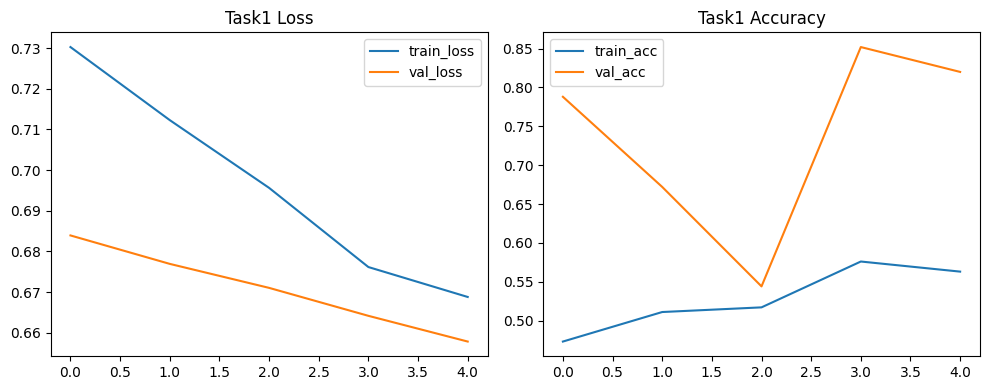

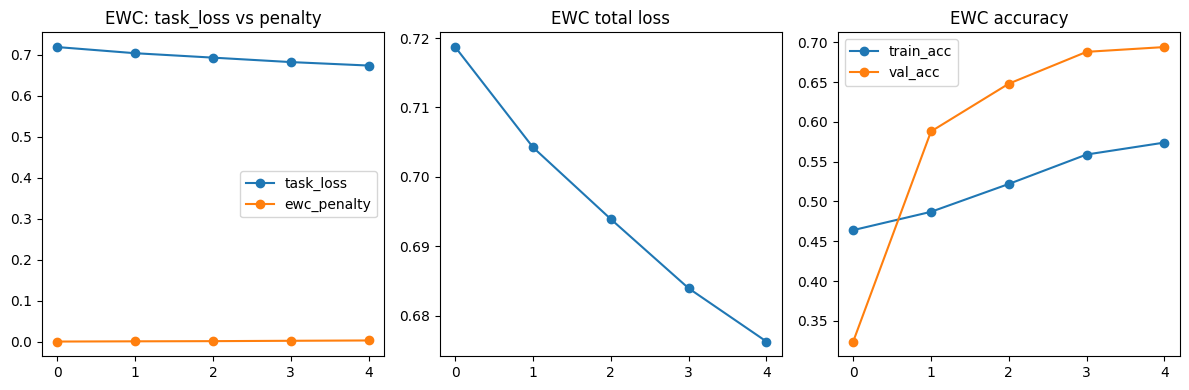

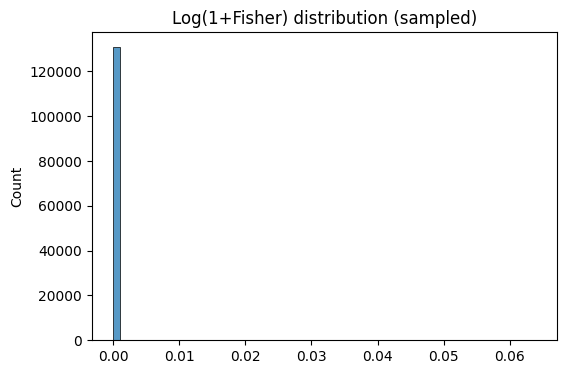

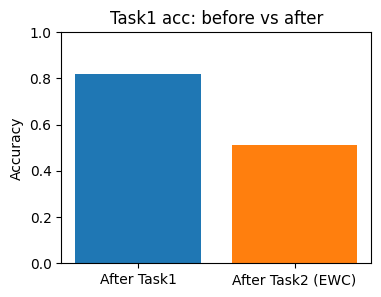

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 301ms/step


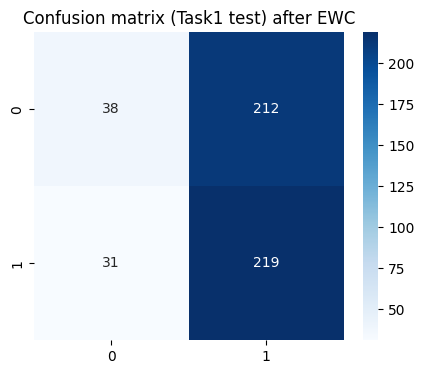



DIAGNOSTIC OUTPUT SUMMARY & INTERPRETATION HELP:
- If [A] Task1 checkpoint on Task1 test is MUCH worse than earlier (~previous run), the starting checkpoint changed.
- If [B] filenames differ from what you expect, sampling changed (different random seed or files).
- If [C] Fisher high percentiles (95% or max) are huge, EWC penalty can dominate training -> consider scaling Fisher or reducing lambda.
- If [D] you see shape mismatches, F and theta_star may not align with model.trainable_variables (this breaks EWC).
- If [E] ewc_penalty >> task_loss each epoch, EWC is likely over-constraining -> reduce lambda or scale F.
- If [F] baseline Task1-ckpt on Task2 is already poor but EWC model is also poor, the issue may be Task2 data/training rather than EWC.

Run these checks and paste the printed outputs here if you want further targeted fixes (lambda scaling, fisher recomputation, variable alignment code snippets, etc.).


In [ ]:
# Complete script (training + EWC) with non-invasive diagnostics A-F
# Requirements: tensorflow, numpy, opencv-python, matplotlib, seaborn, sklearn, tqdm, kagglehub (optional)
# Run in same env as your previous runs.

import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import tensorflow as tf

# ---------------- CONFIG ----------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

USE_KAGGLEHUB = True   # set False if dataset present locally
DATA_DIR = "archive"   # fallback
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 250
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS_TASK1 = 5
EPOCHS_TASK2 = 5
LAMBDA_EWC = 1000.0
FISHER_BATCHES = 50   # number of batches to use for fisher approx (can change later)
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ---------------- LOAD DATA ----------------
if USE_KAGGLEHUB:
    try:
        import kagglehub
        path = kagglehub.dataset_download("puneet6060/intel-image-classification")
        DATA_DIR = path
    except Exception as e:
        print("kagglehub not available or failed:", e)
        DATA_DIR = "archive"

train_dir = os.path.join(DATA_DIR, "seg_train", "seg_train")
test_dir  = os.path.join(DATA_DIR, "seg_test", "seg_test")
assert os.path.exists(train_dir), f"Train dir not found: {train_dir}"
assert os.path.exists(test_dir), f"Test dir not found: {test_dir}"

# Tasks (same as your earlier setup)
classes_task1 = ['sea', 'forest']
classes_task2 = ['buildings', 'mountain']

def downsample_class(class_name, train_dir, test_dir, train_n=TRAIN_PER_CLASS, test_n=TEST_PER_CLASS):
    train_glob = glob.glob(os.path.join(train_dir, class_name, '*.jpg'))
    test_glob  = glob.glob(os.path.join(test_dir, class_name, '*.jpg'))
    if len(train_glob) < train_n or len(test_glob) < test_n:
        raise ValueError(f"Not enough images for class {class_name}. Found train={len(train_glob)}, test={len(test_glob)}")
    train_files = random.sample(train_glob, train_n)
    test_files  = random.sample(test_glob, test_n)
    return train_files, test_files

# Build file lists
train_task1, test_task1 = [], []
for i, cname in enumerate(classes_task1):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task1 += [(f, i) for f in files_train]
    test_task1  += [(f, i) for f in files_test]

train_task2, test_task2 = [], []
for i, cname in enumerate(classes_task2):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task2 += [(f, i) for f in files_train]
    test_task2  += [(f, i) for f in files_test]

print("Task1 train/test sizes:", len(train_task1), len(test_task1))
print("Task2 train/test sizes:", len(train_task2), len(test_task2))

# ---------------- PREPROCESS ----------------
def preprocess_img_label(img_label_tuples, img_size=IMG_SIZE):
    X, y = [], []
    for img_path, label in tqdm(img_label_tuples, desc="Preprocessing images"):
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError("Could not read image:", img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32) / 255.0
        X.append(img)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_train_1, y_train_1 = preprocess_img_label(train_task1)
X_test_1,  y_test_1  = preprocess_img_label(test_task1)
X_train_2, y_train_2 = preprocess_img_label(train_task2)
X_test_2,  y_test_2  = preprocess_img_label(test_task2)

# ---------------- MODEL (same as yours) ----------------
def build_resnet_binary(input_shape=(IMG_SIZE,IMG_SIZE,3), freeze_backbone=True):
    base = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = (not freeze_backbone)
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_resnet_binary(freeze_backbone=True)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

# ---------------- TRAIN TASK 1 (unchanged) ----------------
print("\n--- Training Task 1 (unchanged) ---")
history1 = model.fit(X_train_1, y_train_1, epochs=EPOCHS_TASK1,
                     validation_data=(X_test_1, y_test_1), batch_size=BATCH_SIZE)

# Save Task1 checkpoint
task1_ckpt = os.path.join(CHECKPOINT_DIR, "model_after_task1.h5")
model.save(task1_ckpt)
print("Saved Task1 checkpoint:", task1_ckpt)
t1_eval_after = model.evaluate(X_test_1, y_test_1, verbose=0)
print(f"Task1 test after Task1 training: loss={t1_eval_after[0]:.4f}, acc={t1_eval_after[1]:.4f}")

# ---------------- FISHER COMPUTATION (diagonal) ----------------
trainable_vars = model.trainable_variables

def compute_fisher_diagonal_tf(model, X, y, batch_size=BATCH_SIZE, max_batches=FISHER_BATCHES):
    loss_fn = tf.keras.losses.BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
    dataset = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(1000).batch(batch_size)
    fisher_acc = [np.zeros(var.shape, dtype=np.float32) for var in trainable_vars]
    total_seen = 0
    for i, (xb, yb) in enumerate(dataset):
        if i >= max_batches:
            break
        with tf.GradientTape() as tape:
            preds = model(xb, training=False)  # same as before (non-invasive)
            loss = tf.reduce_mean(loss_fn(yb, preds))
        grads = tape.gradient(loss, trainable_vars)
        for j, g in enumerate(grads):
            if g is None:
                continue
            g_np = g.numpy()
            fisher_acc[j] += (g_np ** 2) * xb.shape[0]
        total_seen += xb.shape[0]
    if total_seen == 0:
        raise RuntimeError("No samples seen when computing Fisher.")
    for j in range(len(fisher_acc)):
        fisher_acc[j] /= float(total_seen)
    return fisher_acc

print("\n--- Computing Fisher diagonal (unchanged) ---")
F_task1 = compute_fisher_diagonal_tf(model, X_train_1, y_train_1, batch_size=BATCH_SIZE, max_batches=FISHER_BATCHES)
print("Computed Fisher (sample stats):")
sample_flat = np.concatenate([f.flatten() for f in F_task1[:min(len(F_task1),10)]])
print("Fisher sample mean:", np.mean(sample_flat), "5%:", np.percentile(sample_flat,5), "95%:", np.percentile(sample_flat,95), "max:", np.max(sample_flat))

theta_star = [var.numpy().copy() for var in trainable_vars]

# ---------------- TRAIN TASK 2 WITH EWC (unchanged) ----------------
def train_with_ewc_tf(model, X_train, y_train, X_val, y_val,
                      fisher_diagonal, theta_star,
                      lambda_ewc=LAMBDA_EWC, epochs=EPOCHS_TASK2, batch_size=BATCH_SIZE, lr=1e-4):
    optimizer = tf.keras.optimizers.Adam(lr)
    loss_fn = tf.keras.losses.BinaryCrossentropy()
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size)
    val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

    fisher_tf = [tf.constant(f.astype(np.float32)) for f in fisher_diagonal]
    theta_tf  = [tf.constant(t.astype(np.float32)) for t in theta_star]

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[],
               'task_loss_epoch':[], 'ewc_penalty_epoch':[], 'total_loss_epoch':[]}

    for epoch in range(epochs):
        print(f"\nEWC Epoch {epoch+1}/{epochs}")
        train_loss = 0.0
        epoch_task_loss_sum = 0.0
        epoch_ewc_sum = 0.0
        steps = 0
        metric_acc = tf.keras.metrics.BinaryAccuracy()

        for xb, yb in train_ds:
            with tf.GradientTape() as tape:
                preds = model(xb, training=True)
                task_loss = tf.reduce_mean(loss_fn(yb, preds))
                ewc_pen = 0.0
                for var, f, t in zip(model.trainable_variables, fisher_tf, theta_tf):
                    ewc_pen += tf.reduce_sum(f * tf.square(var - t))
                ewc_pen *= (0.5 * lambda_ewc)
                loss = task_loss + ewc_pen
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            train_loss += loss.numpy()
            epoch_task_loss_sum += task_loss.numpy()
            epoch_ewc_sum += ewc_pen.numpy()
            metric_acc.update_state(yb, preds)
            steps += 1

        # validation
        val_loss_metric = tf.keras.metrics.Mean()
        val_acc_metric  = tf.keras.metrics.BinaryAccuracy()
        for xb, yb in val_ds:
            preds = model(xb, training=False)
            val_loss_metric.update_state(tf.reduce_mean(loss_fn(yb, preds)))
            val_acc_metric.update_state(yb, preds)

        avg_train_loss = train_loss / max(1, steps)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(metric_acc.result().numpy())
        history['val_loss'].append(val_loss_metric.result().numpy())
        history['val_acc'].append(val_acc_metric.result().numpy())
        history['task_loss_epoch'].append(epoch_task_loss_sum / max(1, steps))
        history['ewc_penalty_epoch'].append(epoch_ewc_sum / max(1, steps))
        history['total_loss_epoch'].append(avg_train_loss)

        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {metric_acc.result().numpy():.4f}")
        print(f"Val   Loss: {val_loss_metric.result().numpy():.4f}, Val   Acc: {val_acc_metric.result().numpy():.4f}")

    return model, history

print("\n--- Training Task 2 with EWC (unchanged) ---")
model, history_ewc = train_with_ewc_tf(
    model,
    X_train_2, y_train_2,
    X_test_2, y_test_2,
    fisher_diagonal=F_task1,
    theta_star=theta_star,
    lambda_ewc=LAMBDA_EWC,
    epochs=EPOCHS_TASK2,
    batch_size=BATCH_SIZE,
    lr=1e-4
)

final_ckpt = os.path.join(CHECKPOINT_DIR, "model_after_task2_ewc.h5")
model.save(final_ckpt)
print("Saved final model:", final_ckpt)

# ---------------- DIAGNOSTIC CHECKS A-F (non-invasive) ----------------
print("\n\n=== DIAGNOSTIC CHECKS (A-F) ===")

# A. Confirm Task-1 checkpoint performance matches expected
try:
    ckpt_model = tf.keras.models.load_model(task1_ckpt, compile=False)
    ckpt_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    eval_t1_ckpt = ckpt_model.evaluate(X_test_1, y_test_1, verbose=0)
    eval_t2_ckpt = ckpt_model.evaluate(X_test_2, y_test_2, verbose=0)
    print("\n[A] Task1 checkpoint evaluation:")
    print("  - Task1 ckpt on Task1 test: loss={:.4f}, acc={:.4f}".format(eval_t1_ckpt[0], eval_t1_ckpt[1]))
    print("  - Task1 ckpt on Task2 test: loss={:.4f}, acc={:.4f}".format(eval_t2_ckpt[0], eval_t2_ckpt[1]))
except Exception as e:
    print("[A] Could not load or evaluate Task1 checkpoint:", e)

# B. Verify sampled filenames for Task1/Task2 (first 10) to detect sampling differences
print("\n[B] Sample filenames used (first 10 each):")
print(" Task1 train samples:", [p for p,_ in train_task1[:10]])
print(" Task2 train samples:", [p for p,_ in train_task2[:10]])

# C. Inspect Fisher statistics
flat_f = np.concatenate([f.flatten() for f in F_task1 if f.size>0])
print("\n[C] Fisher statistics (Task1):")
print("  - total params sampled:", flat_f.size)
print("  - min, 5%, median, 95%, max:", np.min(flat_f), np.percentile(flat_f,5),
      np.median(flat_f), np.percentile(flat_f,95), np.max(flat_f))

# D. Confirm variable alignment (shapes and ordering)
print("\n[D] Checking trainable variable / fisher / theta alignment (first 15 entries):")
mismatch_found = False
for i, (var, f_arr, t_arr) in enumerate(zip(model.trainable_variables, F_task1, theta_star)):
    if var.shape != f_arr.shape:
        print(f"  MISMATCH at idx {i}: var {var.name} shape {var.shape} vs fisher shape {f_arr.shape}")
        mismatch_found = True
    if var.shape != t_arr.shape:
        print(f"  MISMATCH theta at idx {i}: var {var.name} shape {var.shape} vs theta_star shape {t_arr.shape}")
        mismatch_found = True
    if i >= 14:
        break
if not mismatch_found:
    print("  No shape mismatches detected in first 15 variables. (Check full list if needed)")

# E. Print EWC penalty and task loss per epoch
print("\n[E] EWC training stats per epoch:")
for e in range(len(history_ewc['task_loss_epoch'])):
    print(f" Epoch {e+1}: task_loss={history_ewc['task_loss_epoch'][e]:.4f}, ewc_penalty={history_ewc['ewc_penalty_epoch'][e]:.4f}, total_loss={history_ewc['total_loss_epoch'][e]:.4f}, val_acc={history_ewc['val_acc'][e]:.4f}")

# F. Evaluate Task2 performance using Task1 checkpoint (no-EWC baseline)
print("\n[F] Baseline (Task1 ckpt) evaluated on Task2 test (no EWC):")
try:
    baseline_eval_t2 = ckpt_model.evaluate(X_test_2, y_test_2, verbose=0)
    print("  Baseline Task1 ckpt on Task2 test: loss={:.4f}, acc={:.4f}".format(baseline_eval_t2[0], baseline_eval_t2[1]))
except Exception as e:
    print("  Could not evaluate baseline on Task2:", e)

# Also evaluate final EWC model on Task1 and Task2
print("\nFinal EWC model evaluations:")
eval_t1_final = model.evaluate(X_test_1, y_test_1, verbose=0)
eval_t2_final = model.evaluate(X_test_2, y_test_2, verbose=0)
print(" - Final model on Task1 test: loss={:.4f}, acc={:.4f}".format(eval_t1_final[0], eval_t1_final[1]))
print(" - Final model on Task2 test: loss={:.4f}, acc={:.4f}".format(eval_t2_final[0], eval_t2_final[1]))

# ---------------- QUICK PLOTTING (non-invasive visuals) ----------------
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Task1 training curves (history1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label='train_loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.title('Task1 Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history1.history['accuracy'], label='train_acc')
plt.plot(history1.history['val_accuracy'], label='val_acc')
plt.title('Task1 Accuracy'); plt.legend()
plt.tight_layout()
plt.show()

# Plot EWC training curves
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history_ewc['task_loss_epoch'], marker='o', label='task_loss')
plt.plot(history_ewc['ewc_penalty_epoch'], marker='o', label='ewc_penalty')
plt.title('EWC: task_loss vs penalty'); plt.legend()
plt.subplot(1,3,2)
plt.plot(history_ewc['total_loss_epoch'], marker='o'); plt.title('EWC total loss')
plt.subplot(1,3,3)
plt.plot(history_ewc['train_acc'], marker='o', label='train_acc')
plt.plot(history_ewc['val_acc'], marker='o', label='val_acc')
plt.title('EWC accuracy'); plt.legend()
plt.tight_layout(); plt.show()

# Fisher histogram (sample)
sample_flat = flat_f
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(sample_flat), bins=60)
plt.title('Log(1+Fisher) distribution (sampled)')
plt.show()

# Bar: Task1 acc before vs after
acc_t1_after = history1.history['val_accuracy'][-1]
acc_t1_after_ewc = eval_t1_final[1]
plt.figure(figsize=(4,3))
plt.bar(['After Task1','After Task2 (EWC)'], [acc_t1_after, acc_t1_after_ewc], color=['tab:blue','tab:orange'])
plt.ylim(0,1); plt.ylabel('Accuracy'); plt.title('Task1 acc: before vs after')
plt.show()

# Confusion matrix for Task1 after EWC
preds_t1 = (model.predict(X_test_1) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test_1, preds_t1)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix (Task1 test) after EWC')
plt.show()

# ---------------- PRINT GUIDANCE ----------------
print("\n\nDIAGNOSTIC OUTPUT SUMMARY & INTERPRETATION HELP:")
print("- If [A] Task1 checkpoint on Task1 test is MUCH worse than earlier (~previous run), the starting checkpoint changed.")
print("- If [B] filenames differ from what you expect, sampling changed (different random seed or files).")
print("- If [C] Fisher high percentiles (95% or max) are huge, EWC penalty can dominate training -> consider scaling Fisher or reducing lambda.")
print("- If [D] you see shape mismatches, F and theta_star may not align with model.trainable_variables (this breaks EWC).")
print("- If [E] ewc_penalty >> task_loss each epoch, EWC is likely over-constraining -> reduce lambda or scale F.")
print("- If [F] baseline Task1-ckpt on Task2 is already poor but EWC model is also poor, the issue may be Task2 data/training rather than EWC.")

print("\nRun these checks and paste the printed outputs here if you want further targeted fixes (lambda scaling, fisher recomputation, variable alignment code snippets, etc.).")

# End of script

Task1 train/test sizes: 1000 500
Task2 train/test sizes: 1000 500


Preprocessing images: 100%|██████████| 500/500 [00:00<00:00, 1341.99it/s]



--- Training Task 1 (unchanged) ---
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 397ms/step - accuracy: 0.5049 - loss: 0.7147 - val_accuracy: 0.7880 - val_loss: 0.6839
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.5258 - loss: 0.7085 - val_accuracy: 0.6720 - val_loss: 0.6769
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5019 - loss: 0.7022 - val_accuracy: 0.5440 - val_loss: 0.6710
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5733 - loss: 0.6743 - val_accuracy: 0.8520 - val_loss: 0.6642
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5530 - loss: 0.6764 - val_accuracy: 0.8200 - val_loss: 0.6578


Saved Task1 checkpoint: checkpoints/model_after_task1.h5
Task1 test after Task1 training: loss=0.6578, acc=0.8200

--- Computing Fisher diagonal (unchanged) ---
Computed Fisher (sample stats):
Fisher sample mean: 1.5851778e-05 5%: 0.0 95%: 8.288625e-08 max: 0.06600131

--- Training Task 2 with EWC (unchanged) ---

EWC Epoch 1/5
Train Loss: 0.7187, Train Acc: 0.4640
Val   Loss: 0.7023, Val   Acc: 0.3240

EWC Epoch 2/5
Train Loss: 0.7042, Train Acc: 0.4870
Val   Loss: 0.6915, Val   Acc: 0.5880

EWC Epoch 3/5
Train Loss: 0.6939, Train Acc: 0.5220
Val   Loss: 0.6810, Val   Acc: 0.6480

EWC Epoch 4/5
Train Loss: 0.6839, Train Acc: 0.5590
Val   Loss: 0.6697, Val   Acc: 0.6880

EWC Epoch 5/5


Train Loss: 0.6763, Train Acc: 0.5740
Val   Loss: 0.6588, Val   Acc: 0.6940
Saved final model: checkpoints/model_after_task2_ewc.h5


=== DIAGNOSTIC CHECKS (A-F) ===

[A] Task1 checkpoint evaluation:
  - Task1 ckpt on Task1 test: loss=0.6578, acc=0.8200
  - Task1 ckpt on Task2 test: loss=0.7207, acc=0.2580

[B] Sample filenames used (first 10 each):
 Task1 train samples: ['/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/1251.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/15073.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/2042.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/19367.jpg', '/root/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train/sea/18761.jpg', '/root/.cache/kagglehub/datasets/pune

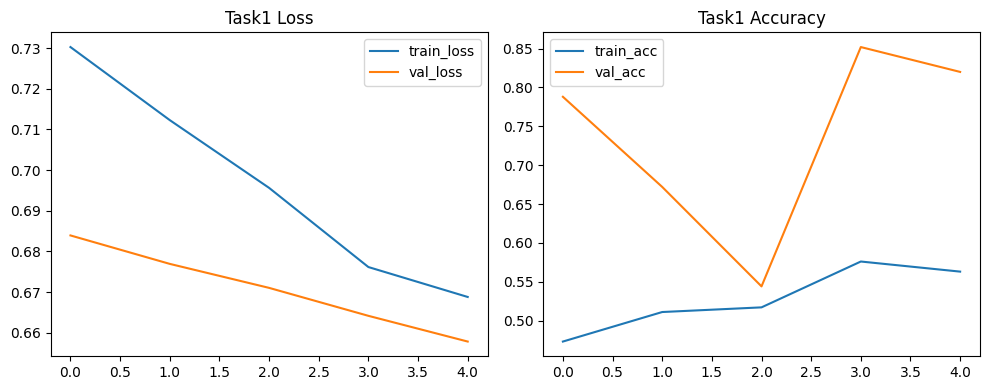

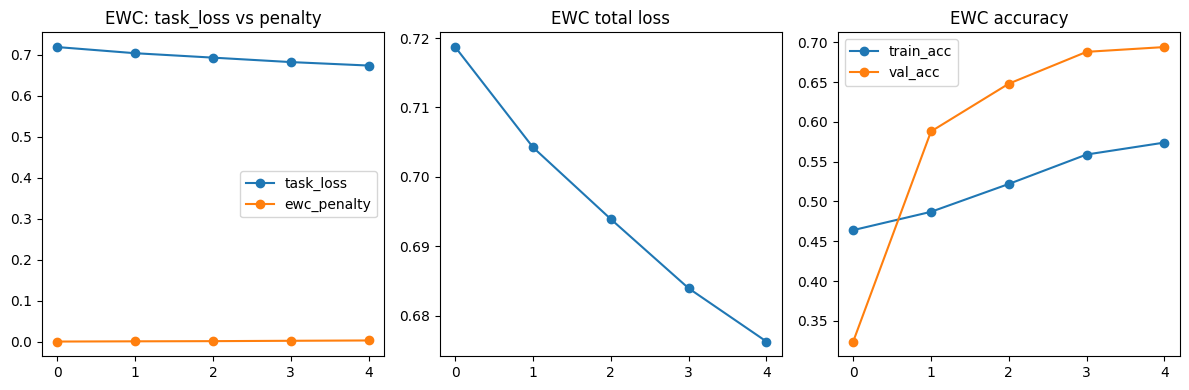

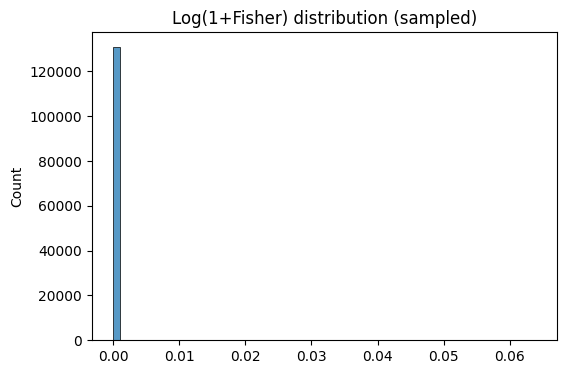

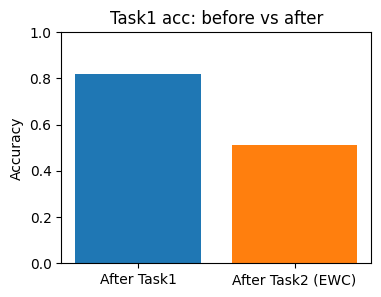

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 348ms/step


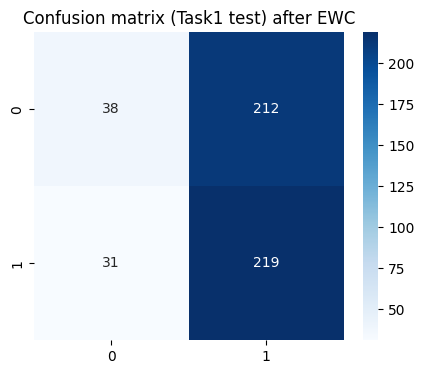



DIAGNOSTIC OUTPUT SUMMARY & INTERPRETATION HELP:
- If [A] Task1 checkpoint on Task1 test is MUCH worse than earlier (~previous run), the starting checkpoint changed.
- If [B] filenames differ from what you expect, sampling changed (different random seed or files).
- If [C] Fisher high percentiles (95% or max) are huge, EWC penalty can dominate training -> consider scaling Fisher or reducing lambda.
- If [D] you see shape mismatches, F and theta_star may not align with model.trainable_variables (this breaks EWC).
- If [E] ewc_penalty >> task_loss each epoch, EWC is likely over-constraining -> reduce lambda or scale F.
- If [F] baseline Task1-ckpt on Task2 is already poor but EWC model is also poor, the issue may be Task2 data/training rather than EWC.

Run these checks and paste the printed outputs here if you want further targeted fixes (lambda scaling, fisher recomputation, variable alignment code snippets, etc.).


In [ ]:
# Complete script (training + EWC) with non-invasive diagnostics A-F
# Requirements: tensorflow, numpy, opencv-python, matplotlib, seaborn, sklearn, tqdm, kagglehub (optional)
# Run in same env as your previous runs.

import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import tensorflow as tf

# ---------------- CONFIG ----------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

USE_KAGGLEHUB = True   # set False if dataset present locally
DATA_DIR = "archive"   # fallback
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 250
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS_TASK1 = 5
EPOCHS_TASK2 = 5
LAMBDA_EWC = 1000.0
FISHER_BATCHES = 50   # number of batches to use for fisher approx (can change later)
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ---------------- LOAD DATA ----------------
if USE_KAGGLEHUB:
    try:
        import kagglehub
        path = kagglehub.dataset_download("puneet6060/intel-image-classification")
        DATA_DIR = path
    except Exception as e:
        print("kagglehub not available or failed:", e)
        DATA_DIR = "archive"

train_dir = os.path.join(DATA_DIR, "seg_train", "seg_train")
test_dir  = os.path.join(DATA_DIR, "seg_test", "seg_test")
assert os.path.exists(train_dir), f"Train dir not found: {train_dir}"
assert os.path.exists(test_dir), f"Test dir not found: {test_dir}"

# Tasks (same as your earlier setup)
classes_task1 = ['sea', 'forest']
classes_task2 = ['buildings', 'mountain']

def downsample_class(class_name, train_dir, test_dir, train_n=TRAIN_PER_CLASS, test_n=TEST_PER_CLASS):
    train_glob = glob.glob(os.path.join(train_dir, class_name, '*.jpg'))
    test_glob  = glob.glob(os.path.join(test_dir, class_name, '*.jpg'))
    if len(train_glob) < train_n or len(test_glob) < test_n:
        raise ValueError(f"Not enough images for class {class_name}. Found train={len(train_glob)}, test={len(test_glob)}")
    train_files = random.sample(train_glob, train_n)
    test_files  = random.sample(test_glob, test_n)
    return train_files, test_files

# Build file lists
train_task1, test_task1 = [], []
for i, cname in enumerate(classes_task1):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task1 += [(f, i) for f in files_train]
    test_task1  += [(f, i) for f in files_test]

train_task2, test_task2 = [], []
for i, cname in enumerate(classes_task2):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task2 += [(f, i) for f in files_train]
    test_task2  += [(f, i) for f in files_test]

print("Task1 train/test sizes:", len(train_task1), len(test_task1))
print("Task2 train/test sizes:", len(train_task2), len(test_task2))

# ---------------- PREPROCESS ----------------
def preprocess_img_label(img_label_tuples, img_size=IMG_SIZE):
    X, y = [], []
    for img_path, label in tqdm(img_label_tuples, desc="Preprocessing images"):
        img = cv2.imread(img_path)
        if img is None:
            raise ValueError("Could not read image:", img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype(np.float32) / 255.0
        X.append(img)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_train_1, y_train_1 = preprocess_img_label(train_task1)
X_test_1,  y_test_1  = preprocess_img_label(test_task1)
X_train_2, y_train_2 = preprocess_img_label(train_task2)
X_test_2,  y_test_2  = preprocess_img_label(test_task2)

# ---------------- MODEL (same as yours) ----------------
def build_resnet_binary(input_shape=(IMG_SIZE,IMG_SIZE,3), freeze_backbone=True):
    base = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = (not freeze_backbone)
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_resnet_binary(freeze_backbone=True)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

# ---------------- TRAIN TASK 1 (unchanged) ----------------
print("\n--- Training Task 1 (unchanged) ---")
history1 = model.fit(X_train_1, y_train_1, epochs=EPOCHS_TASK1,
                     validation_data=(X_test_1, y_test_1), batch_size=BATCH_SIZE)

# Save Task1 checkpoint
task1_ckpt = os.path.join(CHECKPOINT_DIR, "model_after_task1.h5")
model.save(task1_ckpt)
print("Saved Task1 checkpoint:", task1_ckpt)
t1_eval_after = model.evaluate(X_test_1, y_test_1, verbose=0)
print(f"Task1 test after Task1 training: loss={t1_eval_after[0]:.4f}, acc={t1_eval_after[1]:.4f}")

# ---------------- FISHER COMPUTATION (diagonal) ----------------
trainable_vars = model.trainable_variables

def compute_fisher_diagonal_tf(model, X, y, batch_size=BATCH_SIZE, max_batches=FISHER_BATCHES):
    loss_fn = tf.keras.losses.BinaryCrossentropy(reduction=tf.keras.losses.Reduction.NONE)
    dataset = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(1000).batch(batch_size)
    fisher_acc = [np.zeros(var.shape, dtype=np.float32) for var in trainable_vars]
    total_seen = 0
    for i, (xb, yb) in enumerate(dataset):
        if i >= max_batches:
            break
        with tf.GradientTape() as tape:
            preds = model(xb, training=False)  # same as before (non-invasive)
            loss = tf.reduce_mean(loss_fn(yb, preds))
        grads = tape.gradient(loss, trainable_vars)
        for j, g in enumerate(grads):
            if g is None:
                continue
            g_np = g.numpy()
            fisher_acc[j] += (g_np ** 2) * xb.shape[0]
        total_seen += xb.shape[0]
    if total_seen == 0:
        raise RuntimeError("No samples seen when computing Fisher.")
    for j in range(len(fisher_acc)):
        fisher_acc[j] /= float(total_seen)
    return fisher_acc

print("\n--- Computing Fisher diagonal (unchanged) ---")
F_task1 = compute_fisher_diagonal_tf(model, X_train_1, y_train_1, batch_size=BATCH_SIZE, max_batches=FISHER_BATCHES)
print("Computed Fisher (sample stats):")
sample_flat = np.concatenate([f.flatten() for f in F_task1[:min(len(F_task1),10)]])
print("Fisher sample mean:", np.mean(sample_flat), "5%:", np.percentile(sample_flat,5), "95%:", np.percentile(sample_flat,95), "max:", np.max(sample_flat))

theta_star = [var.numpy().copy() for var in trainable_vars]

# ---------------- TRAIN TASK 2 WITH EWC (unchanged) ----------------
def train_with_ewc_tf(model, X_train, y_train, X_val, y_val,
                      fisher_diagonal, theta_star,
                      lambda_ewc=LAMBDA_EWC, epochs=EPOCHS_TASK2, batch_size=BATCH_SIZE, lr=1e-4):
    optimizer = tf.keras.optimizers.Adam(lr)
    loss_fn = tf.keras.losses.BinaryCrossentropy()
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size)
    val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)

    fisher_tf = [tf.constant(f.astype(np.float32)) for f in fisher_diagonal]
    theta_tf  = [tf.constant(t.astype(np.float32)) for t in theta_star]

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[],
               'task_loss_epoch':[], 'ewc_penalty_epoch':[], 'total_loss_epoch':[]}

    for epoch in range(epochs):
        print(f"\nEWC Epoch {epoch+1}/{epochs}")
        train_loss = 0.0
        epoch_task_loss_sum = 0.0
        epoch_ewc_sum = 0.0
        steps = 0
        metric_acc = tf.keras.metrics.BinaryAccuracy()

        for xb, yb in train_ds:
            with tf.GradientTape() as tape:
                preds = model(xb, training=True)
                task_loss = tf.reduce_mean(loss_fn(yb, preds))
                ewc_pen = 0.0
                for var, f, t in zip(model.trainable_variables, fisher_tf, theta_tf):
                    ewc_pen += tf.reduce_sum(f * tf.square(var - t))
                ewc_pen *= (0.5 * lambda_ewc)
                loss = task_loss + ewc_pen
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            train_loss += loss.numpy()
            epoch_task_loss_sum += task_loss.numpy()
            epoch_ewc_sum += ewc_pen.numpy()
            metric_acc.update_state(yb, preds)
            steps += 1

        # validation
        val_loss_metric = tf.keras.metrics.Mean()
        val_acc_metric  = tf.keras.metrics.BinaryAccuracy()
        for xb, yb in val_ds:
            preds = model(xb, training=False)
            val_loss_metric.update_state(tf.reduce_mean(loss_fn(yb, preds)))
            val_acc_metric.update_state(yb, preds)

        avg_train_loss = train_loss / max(1, steps)
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(metric_acc.result().numpy())
        history['val_loss'].append(val_loss_metric.result().numpy())
        history['val_acc'].append(val_acc_metric.result().numpy())
        history['task_loss_epoch'].append(epoch_task_loss_sum / max(1, steps))
        history['ewc_penalty_epoch'].append(epoch_ewc_sum / max(1, steps))
        history['total_loss_epoch'].append(avg_train_loss)

        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {metric_acc.result().numpy():.4f}")
        print(f"Val   Loss: {val_loss_metric.result().numpy():.4f}, Val   Acc: {val_acc_metric.result().numpy():.4f}")

    return model, history

print("\n--- Training Task 2 with EWC (unchanged) ---")
model, history_ewc = train_with_ewc_tf(
    model,
    X_train_2, y_train_2,
    X_test_2, y_test_2,
    fisher_diagonal=F_task1,
    theta_star=theta_star,
    lambda_ewc=LAMBDA_EWC,
    epochs=EPOCHS_TASK2,
    batch_size=BATCH_SIZE,
    lr=1e-4
)

final_ckpt = os.path.join(CHECKPOINT_DIR, "model_after_task2_ewc.h5")
model.save(final_ckpt)
print("Saved final model:", final_ckpt)

# ---------------- DIAGNOSTIC CHECKS A-F (non-invasive) ----------------
print("\n\n=== DIAGNOSTIC CHECKS (A-F) ===")

# A. Confirm Task-1 checkpoint performance matches expected
try:
    ckpt_model = tf.keras.models.load_model(task1_ckpt, compile=False)
    ckpt_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    eval_t1_ckpt = ckpt_model.evaluate(X_test_1, y_test_1, verbose=0)
    eval_t2_ckpt = ckpt_model.evaluate(X_test_2, y_test_2, verbose=0)
    print("\n[A] Task1 checkpoint evaluation:")
    print("  - Task1 ckpt on Task1 test: loss={:.4f}, acc={:.4f}".format(eval_t1_ckpt[0], eval_t1_ckpt[1]))
    print("  - Task1 ckpt on Task2 test: loss={:.4f}, acc={:.4f}".format(eval_t2_ckpt[0], eval_t2_ckpt[1]))
except Exception as e:
    print("[A] Could not load or evaluate Task1 checkpoint:", e)

# B. Verify sampled filenames for Task1/Task2 (first 10) to detect sampling differences
print("\n[B] Sample filenames used (first 10 each):")
print(" Task1 train samples:", [p for p,_ in train_task1[:10]])
print(" Task2 train samples:", [p for p,_ in train_task2[:10]])

# C. Inspect Fisher statistics
flat_f = np.concatenate([f.flatten() for f in F_task1 if f.size>0])
print("\n[C] Fisher statistics (Task1):")
print("  - total params sampled:", flat_f.size)
print("  - min, 5%, median, 95%, max:", np.min(flat_f), np.percentile(flat_f,5),
      np.median(flat_f), np.percentile(flat_f,95), np.max(flat_f))

# D. Confirm variable alignment (shapes and ordering)
print("\n[D] Checking trainable variable / fisher / theta alignment (first 15 entries):")
mismatch_found = False
for i, (var, f_arr, t_arr) in enumerate(zip(model.trainable_variables, F_task1, theta_star)):
    if var.shape != f_arr.shape:
        print(f"  MISMATCH at idx {i}: var {var.name} shape {var.shape} vs fisher shape {f_arr.shape}")
        mismatch_found = True
    if var.shape != t_arr.shape:
        print(f"  MISMATCH theta at idx {i}: var {var.name} shape {var.shape} vs theta_star shape {t_arr.shape}")
        mismatch_found = True
    if i >= 14:
        break
if not mismatch_found:
    print("  No shape mismatches detected in first 15 variables. (Check full list if needed)")

# E. Print EWC penalty and task loss per epoch
print("\n[E] EWC training stats per epoch:")
for e in range(len(history_ewc['task_loss_epoch'])):
    print(f" Epoch {e+1}: task_loss={history_ewc['task_loss_epoch'][e]:.4f}, ewc_penalty={history_ewc['ewc_penalty_epoch'][e]:.4f}, total_loss={history_ewc['total_loss_epoch'][e]:.4f}, val_acc={history_ewc['val_acc'][e]:.4f}")

# F. Evaluate Task2 performance using Task1 checkpoint (no-EWC baseline)
print("\n[F] Baseline (Task1 ckpt) evaluated on Task2 test (no EWC):")
try:
    baseline_eval_t2 = ckpt_model.evaluate(X_test_2, y_test_2, verbose=0)
    print("  Baseline Task1 ckpt on Task2 test: loss={:.4f}, acc={:.4f}".format(baseline_eval_t2[0], baseline_eval_t2[1]))
except Exception as e:
    print("  Could not evaluate baseline on Task2:", e)

# Also evaluate final EWC model on Task1 and Task2
print("\nFinal EWC model evaluations:")
eval_t1_final = model.evaluate(X_test_1, y_test_1, verbose=0)
eval_t2_final = model.evaluate(X_test_2, y_test_2, verbose=0)
print(" - Final model on Task1 test: loss={:.4f}, acc={:.4f}".format(eval_t1_final[0], eval_t1_final[1]))
print(" - Final model on Task2 test: loss={:.4f}, acc={:.4f}".format(eval_t2_final[0], eval_t2_final[1]))

# ---------------- QUICK PLOTTING (non-invasive visuals) ----------------
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Task1 training curves (history1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history1.history['loss'], label='train_loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.title('Task1 Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history1.history['accuracy'], label='train_acc')
plt.plot(history1.history['val_accuracy'], label='val_acc')
plt.title('Task1 Accuracy'); plt.legend()
plt.tight_layout()
plt.show()

# Plot EWC training curves
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.plot(history_ewc['task_loss_epoch'], marker='o', label='task_loss')
plt.plot(history_ewc['ewc_penalty_epoch'], marker='o', label='ewc_penalty')
plt.title('EWC: task_loss vs penalty'); plt.legend()
plt.subplot(1,3,2)
plt.plot(history_ewc['total_loss_epoch'], marker='o'); plt.title('EWC total loss')
plt.subplot(1,3,3)
plt.plot(history_ewc['train_acc'], marker='o', label='train_acc')
plt.plot(history_ewc['val_acc'], marker='o', label='val_acc')
plt.title('EWC accuracy'); plt.legend()
plt.tight_layout(); plt.show()

# Fisher histogram (sample)
sample_flat = flat_f
plt.figure(figsize=(6,4))
sns.histplot(np.log1p(sample_flat), bins=60)
plt.title('Log(1+Fisher) distribution (sampled)')
plt.show()

# Bar: Task1 acc before vs after
acc_t1_after = history1.history['val_accuracy'][-1]
acc_t1_after_ewc = eval_t1_final[1]
plt.figure(figsize=(4,3))
plt.bar(['After Task1','After Task2 (EWC)'], [acc_t1_after, acc_t1_after_ewc], color=['tab:blue','tab:orange'])
plt.ylim(0,1); plt.ylabel('Accuracy'); plt.title('Task1 acc: before vs after')
plt.show()

# Confusion matrix for Task1 after EWC
preds_t1 = (model.predict(X_test_1) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test_1, preds_t1)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion matrix (Task1 test) after EWC')
plt.show()

# ---------------- PRINT GUIDANCE ----------------
print("\n\nDIAGNOSTIC OUTPUT SUMMARY & INTERPRETATION HELP:")
print("- If [A] Task1 checkpoint on Task1 test is MUCH worse than earlier (~previous run), the starting checkpoint changed.")
print("- If [B] filenames differ from what you expect, sampling changed (different random seed or files).")
print("- If [C] Fisher high percentiles (95% or max) are huge, EWC penalty can dominate training -> consider scaling Fisher or reducing lambda.")
print("- If [D] you see shape mismatches, F and theta_star may not align with model.trainable_variables (this breaks EWC).")
print("- If [E] ewc_penalty >> task_loss each epoch, EWC is likely over-constraining -> reduce lambda or scale F.")
print("- If [F] baseline Task1-ckpt on Task2 is already poor but EWC model is also poor, the issue may be Task2 data/training rather than EWC.")

print("\nRun these checks and paste the printed outputs here if you want further targeted fixes (lambda scaling, fisher recomputation, variable alignment code snippets, etc.).")

# End of script